# 01 - Data Exploration (ULB Credit Card Fraud)

In [1]:
import sys, os
sys.path.insert(0, r"D:\Quantum Credit Card Fraud Detection")
os.chdir(r"D:\Quantum Credit Card Fraud Detection")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")


## Overview

This notebook explores the **ULB Credit Card Fraud** dataset (primary reproducibility
benchmark, spec section 3). If `data/raw/creditcard.csv` is not present (e.g. no Kaggle
download has been done), we fall back to a clearly-labeled **synthetic** sample with the
same schema (`Time`, `V1..V28`, `Amount`, `Class`) purely for demonstration — real research
conclusions must be drawn from the real dataset, downloaded via `scripts/download_data.py`.

In [2]:
from src.data.loaders import load_dataset, load_synthetic
from src.data.validators import validate_dataset

try:
    ds = load_dataset("ulb")
    print("Loaded REAL ULB data.")
except FileNotFoundError as e:
    print("Real ULB data not found locally -> using a SYNTHETIC sample instead.\n")
    ds = load_synthetic("ulb", n_samples=8000, random_state=42)

print(f"is_synthetic = {ds.is_synthetic}")
ds.frame.head()


Real ULB data not found locally -> using a SYNTHETIC sample instead.

is_synthetic = True


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,47306.473292,1.879884,0.273236,-1.473302,0.211303,0.340883,0.983539,-1.146728,0.427032,3.401870,...,-0.236764,-0.083529,-0.367139,-0.338338,-1.402752,-0.729981,-1.595593,1.044378,101.036838,0
1,55557.690440,1.862335,-1.927939,-0.273421,0.643294,0.815548,1.075197,-0.521275,-1.691373,1.407088,...,1.034142,0.669063,0.464123,0.648588,0.572976,-0.554502,-0.040141,1.090601,36.688611,0
2,35521.806644,-1.402595,3.048133,0.189646,-2.129012,1.380668,-0.355230,2.175006,2.086702,0.515484,...,1.280361,2.613872,-0.088086,0.499732,-0.355482,-1.053795,2.361750,2.455053,494.383695,1
3,64695.233784,-0.668375,0.904919,1.162463,0.704648,-0.960996,1.407759,1.229325,0.599585,0.204348,...,-0.627321,1.465660,-0.267711,-0.433427,0.482386,-1.836510,-0.790534,0.981073,120.896171,0
4,92518.472639,0.360649,0.344834,0.367382,0.171363,-0.309954,-0.992849,-0.920344,0.245737,1.064939,...,0.012761,1.418055,-0.703241,-0.098636,0.286396,-0.137927,0.512631,-0.267802,47.202864,0


In [3]:
report = validate_dataset(ds)
print(report.summary())


Dataset: ulb
  rows=8000  columns=31  duplicates=0
  class balance: {'0': 0.98275, '1': 0.01725}


In [4]:
ds.frame.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,8000.0,86228.507267,49895.061119,28.603929,42656.433155,85597.882648,129889.701112,172752.365319
V1,8000.0,-0.000603,1.030172,-4.656771,-0.686032,-0.014862,0.689219,4.632731
V2,8000.0,0.031257,1.023821,-3.854803,-0.642280,0.013580,0.715102,5.009383
V3,8000.0,-0.001610,1.020168,-4.295407,-0.687531,0.001926,0.682911,4.588747
V4,8000.0,0.009998,1.029069,-3.492974,-0.670363,-0.000807,0.673319,4.679867
V5,8000.0,0.020440,1.004427,-3.585304,-0.650922,0.017564,0.672935,5.405459
V6,8000.0,0.027792,1.031870,-4.023626,-0.664056,0.025769,0.710889,5.096128
V7,8000.0,0.008647,1.027537,-4.257009,-0.690711,-0.005973,0.686063,5.974256
V8,8000.0,0.005107,1.016672,-3.887804,-0.694457,-0.001454,0.671827,4.999856
V9,8000.0,0.046623,1.020534,-3.682637,-0.627910,0.016397,0.707195,4.557868


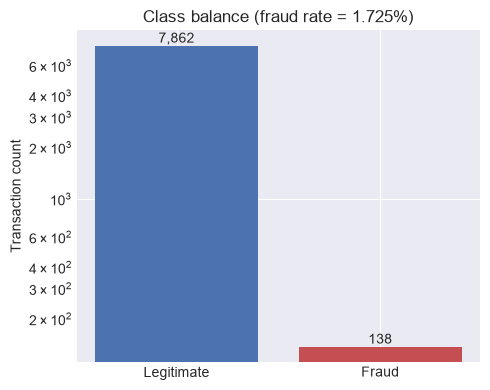

In [5]:
counts = ds.frame["Class"].value_counts().sort_index()
fraud_rate = ds.frame["Class"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Legitimate", "Fraud"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Transaction count")
ax.set_title(f"Class balance (fraud rate = {fraud_rate:.3%})")
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}", ha="center", va="bottom")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\01_class_balance.png")
plt.show()


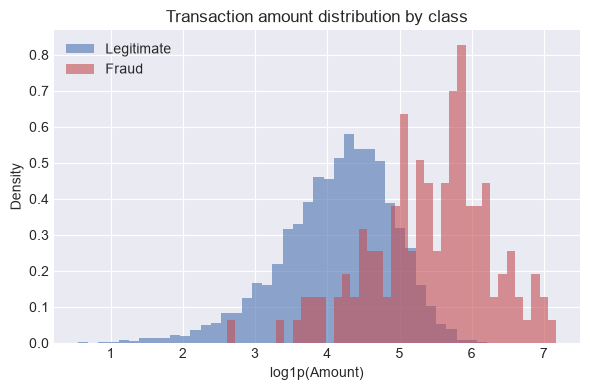

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
for cls, label, color in [(0, "Legitimate", "#4C72B0"), (1, "Fraud", "#C44E52")]:
    subset = ds.frame.loc[ds.frame["Class"] == cls, "Amount"]
    ax.hist(np.log1p(subset), bins=40, alpha=0.6, label=label, color=color, density=True)
ax.set_xlabel("log1p(Amount)")
ax.set_ylabel("Density")
ax.set_title("Transaction amount distribution by class")
ax.legend()
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\01_amount_distribution.png")
plt.show()


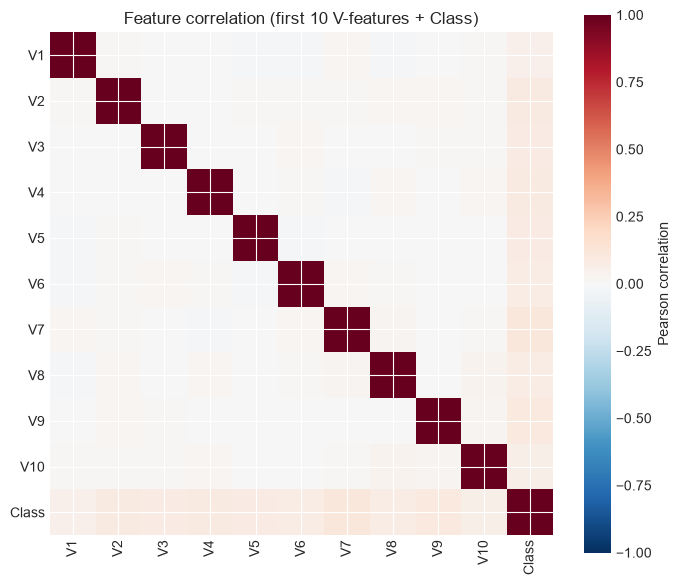

In [7]:
v_cols = [c for c in ds.frame.columns if c.startswith("V")][:10]
corr = ds.frame[v_cols + ["Class"]].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Feature correlation (first 10 V-features + Class)")
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\01_correlation_heatmap.png")
plt.show()
